# OCR Model Benchmark

Evaluates and compares **27 OCR models** on `FlexQube.pdf` using three metrics:

| Metric | Description | Goal |
|--------|-------------|------|
| CER | Character Error Rate | Lower is better |
| WER | Word Error Rate | Lower is better |
| Similarity | Text similarity score | Higher is better |

Models are ranked from best to worst across all three metrics.

In [ ]:
!pip install -q jiwer

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 39.6 MB/s eta 0:00:00


In [ ]:
import re
from jiwer import wer, cer
from difflib import SequenceMatcher

### Normalization function

In [ ]:
def normalize_text(text: str) -> str:
    """Normalize text for fair comparison."""
    text = text.lower()
    text = re.sub(r'<[^>]+>', '', text)  # Remove HTML tags
    text = re.sub(r'\s+', ' ', text)      # Normalize whitespace
    text = re.sub(r'[#*_`()>|=-]+', '', text)  # Remove markdown syntax
    return text.strip()

### Evaluation function

In [ ]:

def evaluate_ocr(ground_truth: str, ocr_output: str, model_name: str) -> dict:
    """Calculate CER, WER, and Similarity Score."""
    gt_normalized = normalize_text(ground_truth)
    ocr_normalized = normalize_text(ocr_output)

    char_error_rate = cer(gt_normalized, ocr_normalized)
    word_error_rate = wer(gt_normalized, ocr_normalized)
    similarity = SequenceMatcher(None, gt_normalized, ocr_normalized).ratio()

    return {
        'model': model_name,
        'cer': char_error_rate,
        'wer': word_error_rate,
        'similarity': similarity,
        'gt_chars': len(gt_normalized),
        'ocr_chars': len(ocr_normalized)
    }


### Load your files

In [ ]:
try:
    from google.colab import files
    print("Upload GROUND TRUTH file:")
    uploaded_gt = files.upload()
    gt_filename = list(uploaded_gt.keys())[0]
    ground_truth = uploaded_gt[gt_filename].decode("utf-8")
except ImportError:
    gt_filename = "data/ground_truth/dataset/ground_truth.md"
    with open(gt_filename, encoding="utf-8") as f:
        ground_truth = f.read()

print(f"Ground truth loaded: {gt_filename} — {len(ground_truth):,} chars")

 Upload GROUND TRUTH file:


Saving ground_truth.md to ground_truth.md
Ground truth loaded: 205,938 chars



In [ ]:
try:
    from google.colab import files
    print("Upload all OCR output files:")
    uploaded_ocr = files.upload()
except ImportError:
    import glob
    folder = "data/models_outputs"
    paths = glob.glob(os.path.join(folder, "*.md"))
    uploaded_ocr = {}
    for p in paths:
        with open(p, encoding="utf-8") as f:
            uploaded_ocr[os.path.basename(p)] = f.read().encode("utf-8")

print(f"\nFiles uploaded: {len(uploaded_ocr)}")

ocr_outputs = {}
for filename, content in uploaded_ocr.items():
    model_name = filename.replace('_output.md', '').replace('_output.txt', '').replace('.md', '').replace('.txt', '')
    ocr_outputs[model_name] = content.decode('utf-8')
    print(f"  {model_name}: {len(ocr_outputs[model_name]):,} chars")

print(f"\n Total loaded: {len(ocr_outputs)} OCR outputs")

Upload all OCR output files:


Saving chandra_output.md to chandra_output.md
Saving deepseek_ocr_output.md to deepseek_ocr_output.md
Saving deepseek_ocr2_output.md to deepseek_ocr2_output.md
Saving docling_output.md to docling_output.md
Saving doctr_output.md to doctr_output.md
Saving easyocr_output.md to easyocr_output.md
Saving florence2_output.md to florence2_output.md
Saving gemini2.5_output.md to gemini2.5_output.md
Saving GLM_ocr_output.md to GLM_ocr_output.md
Saving haiku_output.md to haiku_output.md
Saving hunyuan_output.md to hunyuan_output.md
Saving landingai_output.md to landingai_output.md
Saving latex_output.md to latex_output.md
Saving lightonocr_output.md to lightonocr_output.md
Saving llamaindex.md to llamaindex.md
Saving llamaparse_output.md to llamaparse_output.md
Saving mistral_output.md to mistral_output.md
Saving nemotron_ocr_output.md to nemotron_ocr_output.md
Saving paddle_ocr_output.md to paddle_ocr_output.md
Saving pdfplumber_output.md to pdfplumber_output.md
Saving Qianfan_ocr_output.md to 

### Run evaluation

In [ ]:
results = []
for model_name, ocr_text in ocr_outputs.items():
    result = evaluate_ocr(ground_truth, ocr_text, model_name)
    results.append(result)


In [ ]:

print(f"\n{'Model':<25} {'CER':<12} {'WER':<12} {'Similarity':<12}")
print("-"*70)

results_sorted = sorted(results, key=lambda x: x['cer'])
for r in results_sorted:
    print(f"{r['model']:<25} {r['cer']*100:>6.2f}%     {r['wer']*100:>6.2f}%     {r['similarity']*100:>6.2f}%")

print("-"*50)
print("Lower CER/WER = Better | Higher Similarity = Better")



Model                     CER          WER          Similarity  
----------------------------------------------------------------------
llamaindex                  6.29%       6.71%      90.04%
chandra                    12.34%      12.68%      19.59%
hunyuan                    12.62%      13.00%      74.90%
docling                    21.28%      30.46%      28.24%
deepseek_ocr2              23.11%      33.41%      69.93%
deepseek_ocr               25.70%      34.09%      20.53%
lightonocr                 26.46%      27.26%      44.55%
sonnet4                    37.74%      43.86%      41.01%
trocr                      43.27%      64.20%      29.57%
latex                      48.22%      55.89%      27.14%
mistral                    55.02%      66.84%      23.89%
qwen25                     58.85%      62.31%       9.00%
easyocr                    61.61%      75.92%      16.41%
llamaparse                 63.77%      75.90%      16.13%
gemini2.5                  63.95%      77.22%      

Benchmark document: FlexQube.pdf


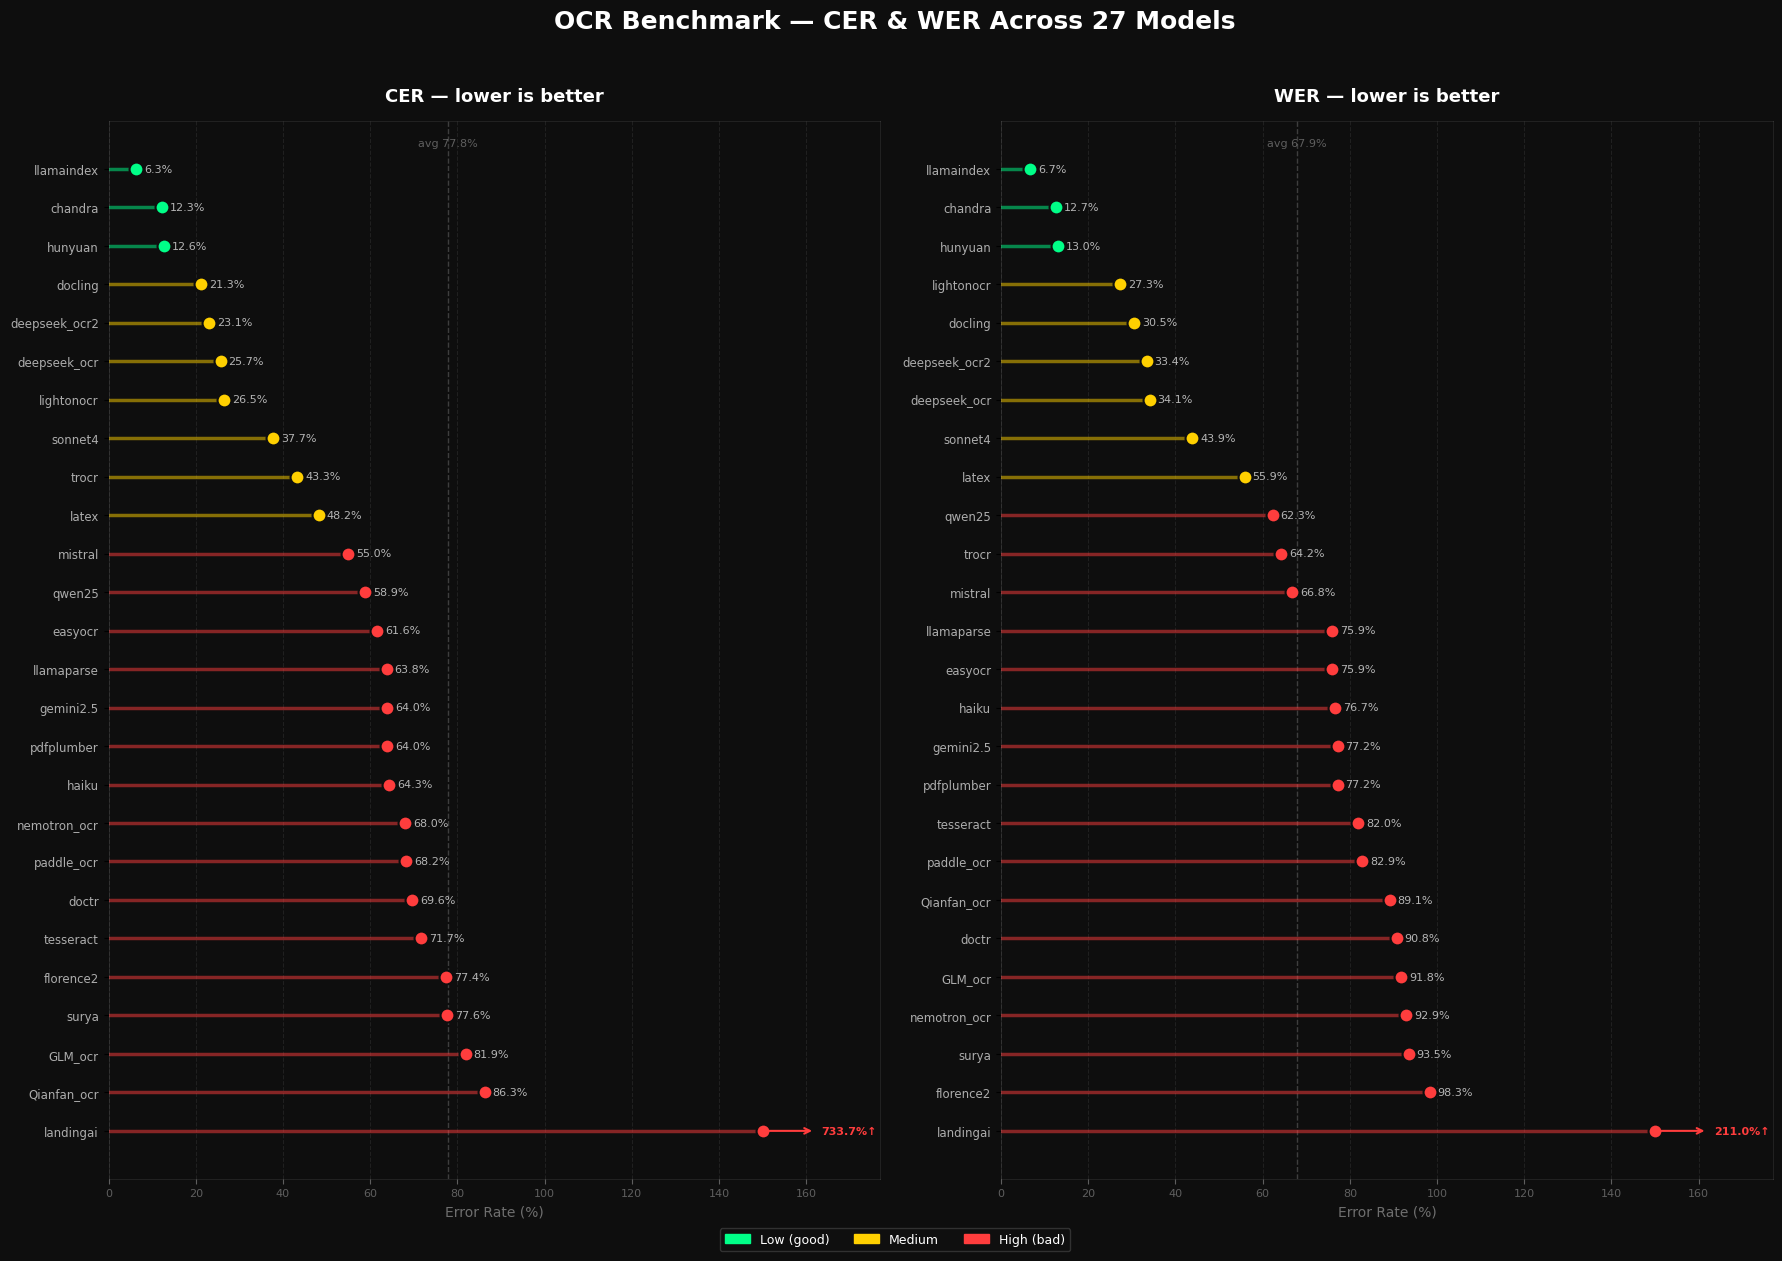

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

def plot_cer_wer_ranking(results: list[dict]) -> None:
    by_cer = sorted(results, key=lambda x: x['cer'])
    by_wer = sorted(results, key=lambda x: x['wer'])

    def get_color_cer(val):
        if val <= 20: return '#00ff88'
        if val <= 50: return '#ffd000'
        return '#ff3d3d'

    def get_color_wer(val):
        if val <= 25: return '#00ff88'
        if val <= 60: return '#ffd000'
        return '#ff3d3d'

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 12))
    fig.patch.set_facecolor('#0e0e0e')
    fig.suptitle('OCR Benchmark — CER & WER Across 27 Models',
                 fontsize=18, fontweight='bold', color='white', y=1.02)

    def render(ax, data, key, get_color, title, clip):
        vals = [r[key] * 100 for r in data]
        names = [r['model'] for r in data]
        y = np.arange(len(data))
        avg = np.mean(vals)
        colors = [get_color(v) for v in vals]

        ax.set_facecolor('#0e0e0e')

        for i, (val, color) in enumerate(zip(vals, colors)):
            clipped = min(val, clip)
            ax.plot([0, clipped], [i, i], color=color, alpha=0.5, linewidth=2.5, solid_capstyle='round', zorder=2)
            ax.scatter(clipped, i, color=color, s=100, zorder=3, edgecolors='#0e0e0e', linewidth=1.5)

            if val > clip:
                ax.annotate('', xy=(clip * 1.08, i), xytext=(clip, i),
                            arrowprops=dict(arrowstyle='->', color=color, lw=1.5))
                ax.text(clip * 1.09, i, f'{val:.1f}%↑',
                        va='center', ha='left', fontsize=8, color=color, fontweight='bold')
            else:
                offset = clip * 0.012
                ax.text(val + offset, i, f'{val:.1f}%',
                        va='center', ha='left', fontsize=8, color='#ffffffb0')

        ax.axvline(avg, color='#ffffff33', linewidth=1, linestyle='--', zorder=1)
        ax.text(avg, -0.8, f'avg {avg:.1f}%', fontsize=8,
                color='#ffffff55', ha='center', va='top')

        ax.set_yticks(y)
        ax.set_yticklabels(names, fontsize=8.5, color='#ffffffa8')
        ax.invert_yaxis()
        ax.set_xlim(0, clip * 1.18)
        ax.set_xlabel('Error Rate (%)', fontsize=10, color='#ffffff66')
        ax.xaxis.grid(True, linestyle='--', alpha=0.08, color='white')
        ax.set_axisbelow(True)
        ax.tick_params(axis='x', colors='#ffffff55', labelsize=8)

        for spine in ax.spines.values():
            spine.set_edgecolor('#ffffff15')

        ax.set_title(title, fontsize=13, fontweight='bold', color='white', pad=14)

    render(ax1, by_cer, 'cer', get_color_cer, 'CER — lower is better', clip=150)
    render(ax2, by_wer, 'wer', get_color_wer, 'WER — lower is better', clip=150)

    legend_elements = [
        mpatches.Patch(color='#00ff88', label='Low (good)'),
        mpatches.Patch(color='#ffd000', label='Medium'),
        mpatches.Patch(color='#ff3d3d', label='High (bad)'),
    ]
    fig.legend(handles=legend_elements, loc='lower center', ncol=3,
               fontsize=9, framealpha=0.15, labelcolor='white',
               facecolor='#1a1a1a', edgecolor='#ffffff22', bbox_to_anchor=(0.5, -0.02))

    plt.tight_layout()
    plt.savefig('ranking_cer_wer.png', dpi=150, bbox_inches='tight', facecolor='#0e0e0e')
    plt.show()

print("Benchmark document: FlexQube.pdf")
plot_cer_wer_ranking(results)

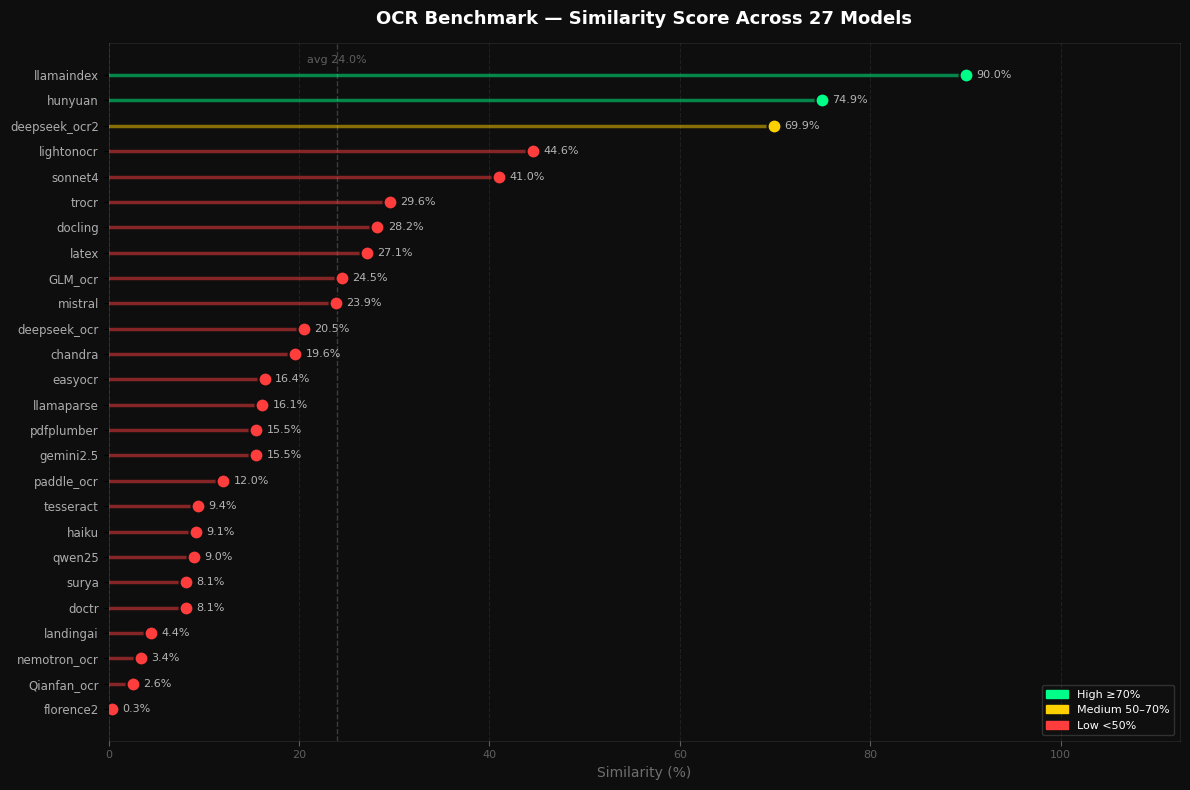

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

def plot_similarity_ranking(results: list[dict]) -> None:
    by_sim = sorted(results, key=lambda x: x['similarity'], reverse=True)
    vals = [r['similarity'] * 100 for r in by_sim]
    names = [r['model'] for r in by_sim]
    n = len(by_sim)
    y = np.arange(n)
    avg = np.mean(vals)

    def get_color(val):
        if val >= 70: return '#00ff88'
        if val >= 50: return '#ffd000'
        return '#ff3d3d'

    colors = [get_color(v) for v in vals]

    fig, ax = plt.subplots(figsize=(12, 8))
    fig.patch.set_facecolor('#0e0e0e')
    ax.set_facecolor('#0e0e0e')

    # Lollipop: linje + cirkel
    for i, (val, color) in enumerate(zip(vals, colors)):
        ax.plot([0, val], [i, i], color=color, alpha=0.5, linewidth=2.5, solid_capstyle='round', zorder=2)
        ax.scatter(val, i, color=color, s=100, zorder=3, edgecolors='#0e0e0e', linewidth=1.5)

    # Värde till höger
    offset = max(vals) * 0.012
    for i, val in enumerate(vals):
        ax.text(val + offset, i, f'{val:.1f}%', va='center', ha='left',
                fontsize=8, color='#ffffffb0')

    # Medelvärdelinje
    ax.axvline(avg, color='#ffffff33', linewidth=1, linestyle='--', zorder=1)
    ax.text(avg, -0.8, f'avg {avg:.1f}%', fontsize=8,
            color='#ffffff55', ha='center', va='top')

    # Legend
    legend_elements = [
        mpatches.Patch(color='#00ff88', label='High ≥70%'),
        mpatches.Patch(color='#ffd000', label='Medium 50–70%'),
        mpatches.Patch(color='#ff3d3d', label='Low <50%'),
    ]
    ax.legend(handles=legend_elements, loc='lower right',
              fontsize=8, framealpha=0.15,
              labelcolor='white', facecolor='#1a1a1a', edgecolor='#ffffff22')

    ax.set_yticks(y)
    ax.set_yticklabels(names, fontsize=8.5, color='#ffffffa8')
    ax.invert_yaxis()
    ax.set_xlim(0, max(vals) * 1.25)
    ax.set_xlabel('Similarity (%)', fontsize=10, color='#ffffff66')
    ax.xaxis.grid(True, linestyle='--', alpha=0.08, color='white')
    ax.set_axisbelow(True)
    ax.tick_params(axis='x', colors='#ffffff55', labelsize=8)

    for spine in ax.spines.values():
        spine.set_edgecolor('#ffffff15')

    ax.set_title('OCR Benchmark — Similarity Score Across 27 Models', fontsize=13,
                 fontweight='bold', color='white', pad=14)

    plt.tight_layout()
    plt.savefig('ranking_similarity.png', dpi=150, bbox_inches='tight',
                facecolor='#0e0e0e')
    plt.show()

plot_similarity_ranking(results)